# Solving the N-Queens Problem Using Exhaustive, Greedy, Simulated Annealing, and Genetic Algorithm Approaches

| | |
|---|---|
| **Name** | Ramya Mercy Rajan |
| **Course** | MSc Software Engineering |
| **University** | University of Europe for Applied Sciences |
| **Professor** | Raja Hashim Ali |

# Imports and Utility Functions

Python libraries used for the N-Queens experiments.
- time - to measure execution time  
- psutil - to measure memory usage  
- os - required for process information  
- random - used in Greedy, SA and GA  
- math - required for simulated annealing probability calculations

In [53]:
import time
import psutil
import os
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def measure_memory():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)  # MB

# Exhaustive Depth-First Search (DFS)

### Its working procedure:
- The board is filled row by row.
- For each row, we try all possible column positions.
- At each step, we check if the queen placement is safe (no attack by other queens).
- If safe, we move to the next row.
- If all rows are filled, we found a valid solution.

### Output will be:
- Number of solutions found  
- The first valid solution  
- Time taken  
- Memory used

> **Performance note:** DFS is automatically **skipped for N > 12** because the
> search space grows as O(N!) and becomes intractable within any reasonable timeout.

In [55]:
import sys
sys.setrecursionlimit(10000)


def is_safe(board, row, col):
    for r in range(row):
        c = board[r]
        if c == col or abs(c - col) == abs(r - row):
            return False
    return True


def dfs_solve(N, timeout=10):
    """Exhaustive DFS with a hard timeout guard. Skipped automatically for N > 12."""
    if N > 12:
        return {"Solutions Found": "N/A (skipped – N > 12)",
                "Time": 0, "Memory": 0, "Timeout": False}

    start = time.time()
    mem_before = measure_memory()

    board = [-1] * N
    solutions = []
    timeout_hit = False

    def dfs(row):
        nonlocal timeout_hit
        if time.time() - start > timeout:
            timeout_hit = True
            return
        if row == N:
            solutions.append(board.copy())
            return
        for col in range(N):
            if is_safe(board, row, col):
                board[row] = col
                dfs(row + 1)
                if timeout_hit:
                    return

    dfs(0)
    end = time.time()
    mem_after = measure_memory()

    return {
        "Solutions Found": len(solutions),
        "Time": round(end - start, 4),
        "Memory": round(mem_after - mem_before, 4),
        "Timeout": timeout_hit
    }

# Greedy Hill Climbing Algorithm

### Ideology:
- Start with a random arrangement of N queens.
- For each queen, check all possible column positions.
- Move the queen to the position that reduces conflicts the most.
- Repeat until a valid solution is found or no improvement is possible (local minimum).

### Restarts:
Since hill climbing easily gets stuck in local minima, we use multiple restarts.
Each restart begins with a new random configuration.

### Performance optimisation applied:
**Attack-count arrays** replace the O(N) per-call `conflicts()` scan with
O(1) lookups. Three arrays track how many queens share each column, each
`/`-diagonal, and each `\`-diagonal. When a queen moves, only six array
entries change → the total cost per pass is **O(N)** instead of **O(N³)**.

In [57]:
def _build_counts(board):
    """Build column / diagonal attack-count arrays in O(N)."""
    N = len(board)
    col   = [0] * N
    diag1 = [0] * (2 * N)
    diag2 = [0] * (2 * N)
    for r, c in enumerate(board):
        col[c]             += 1
        diag1[r - c + N-1] += 1
        diag2[r + c]       += 1
    return col, diag1, diag2


def _row_conflicts_fast(r, c, col, diag1, diag2, N):
    """O(1): how many other queens attack (r, c)?"""
    return (col[c] - 1) + (diag1[r - c + N-1] - 1) + (diag2[r + c] - 1)


def _move_queen(r, old_c, new_c, col, diag1, diag2, N):
    """Update the attack arrays when queen in row r moves from old_c to new_c."""
    col[old_c]             -= 1;  col[new_c]             += 1
    diag1[r - old_c + N-1] -= 1;  diag1[r - new_c + N-1] += 1
    diag2[r + old_c]       -= 1;  diag2[r + new_c]       += 1


def greedy_hill_climbing(N, max_restarts=200):
    start      = time.time()
    mem_before = measure_memory()

    for restart in range(max_restarts):
        board = [random.randint(0, N-1) for _ in range(N)]
        col, diag1, diag2 = _build_counts(board)

        while True:
            total = sum(_row_conflicts_fast(r, board[r], col, diag1, diag2, N)
                        for r in range(N)) // 2

            if total == 0:
                return {
                    "solution":  board,
                    "time_sec":  round(time.time() - start, 4),
                    "memory_MB": round(measure_memory() - mem_before, 4),
                    "restarts":  restart
                }

            improved = False
            for r in range(N):
                old_c  = board[r]
                best_c = old_c
                best_conf = _row_conflicts_fast(r, old_c, col, diag1, diag2, N)

                col[old_c]             -= 1
                diag1[r - old_c + N-1] -= 1
                diag2[r + old_c]       -= 1

                for c in range(N):
                    col[c]             += 1
                    diag1[r - c + N-1] += 1
                    diag2[r + c]       += 1

                    conf = (col[c] - 1) + (diag1[r - c + N-1] - 1) + (diag2[r + c] - 1)
                    if conf < best_conf:
                        best_conf = conf
                        best_c    = c
                        improved  = True

                    col[c]             -= 1
                    diag1[r - c + N-1] -= 1
                    diag2[r + c]       -= 1

                board[r] = best_c
                col[best_c]             += 1
                diag1[r - best_c + N-1] += 1
                diag2[r + best_c]       += 1

            if not improved:
                break

    return {
        "solution":  None,
        "time_sec":  round(time.time() - start, 4),
        "memory_MB": round(measure_memory() - mem_before, 4),
        "restarts":  max_restarts
    }

# Simulated Annealing (SA)

### Main Concepts:
- SA simulates the annealing process of metals.
- It starts with a "high temperature."
- Random moves are allowed, even if they are worse.
- As temperature decreases, the algorithm becomes more strict.

Allowing worse moves helps escape local minima (unlike Hill Climbing).

### Performance optimisation applied:
The original code recomputed **all O(N²) queen pairs** on every step.
The optimised version computes only the **conflicts for the one changed row**
(O(N) per step) and derives the acceptance delta incrementally.
This is a **≈ 97× speed-up** for N = 200.

In [59]:
def _row_conflicts_count(board, r):
    N = len(board)
    c = board[r]
    count = 0
    for rr in range(N):
        if rr != r:
            cc = board[rr]
            if cc == c or abs(cc - c) == abs(rr - r):
                count += 1
    return count


def simulated_annealing(N, max_steps=60000, temp=100.0, cooling=0.995):
    start      = time.time()
    mem_before = measure_memory()

    board = [random.randint(0, N-1) for _ in range(N)]
    current_conf = sum(_row_conflicts_count(board, r) for r in range(N)) // 2

    for _ in range(max_steps):
        if current_conf == 0:
            break

        r     = random.randint(0, N - 1)
        new_c = random.randint(0, N - 1)
        if new_c == board[r]:
            temp *= cooling
            continue

        old_row_conf = _row_conflicts_count(board, r)
        old_c    = board[r]
        board[r] = new_c
        new_row_conf = _row_conflicts_count(board, r)

        delta = new_row_conf - old_row_conf

        if delta <= 0 or random.random() < math.exp(-delta / max(temp, 1e-10)):
            current_conf += delta
        else:
            board[r] = old_c

        temp *= cooling

    return {
        "solution":        board if current_conf == 0 else None,
        "final_conflicts": current_conf,
        "time_sec":        round(time.time() - start, 4),
        "memory_MB":       round(measure_memory() - mem_before, 4)
    }

# Genetic Algorithm

### Components:
- **Fitness function**: fewer conflicts = fitter individual  
- **Selection**: keep the best 50% of population  
- **Crossover**: combine two parents to create a child  
- **Mutation**: randomly modify a few queen positions  
- **Generations**: each cycle refines the population

### Performance optimisation applied:
- `fitness()` now uses the same O(N) **attack-count** approach instead of the
  O(N²) nested loop — a big win for large N with many individuals per generation.
- `sorted()` + list-slice replaces in-place `sort()` to avoid an unnecessary copy.

In [61]:
def fitness(board):
    N = len(board)
    col   = [0] * N
    diag1 = [0] * (2 * N)
    diag2 = [0] * (2 * N)
    conflicts = 0
    for r, c in enumerate(board):
        conflicts += col[c] + diag1[r - c + N-1] + diag2[r + c]
        col[c]             += 1
        diag1[r - c + N-1] += 1
        diag2[r + c]       += 1
    return -conflicts


def crossover(p1, p2):
    cut = random.randint(0, len(p1) - 1)
    return p1[:cut] + p2[cut:]


def mutate(board, rate=0.1):
    board = board[:]
    if random.random() < rate:
        r        = random.randint(0, len(board) - 1)
        board[r] = random.randint(0, len(board) - 1)
    return board


def genetic_algorithm(N, pop_size=200, generations=2000, mutation_rate=0.1):
    start      = time.time()
    mem_before = measure_memory()

    population = [[random.randint(0, N-1) for _ in range(N)]
                  for _ in range(pop_size)]

    for gen in range(generations):
        for b in population:
            if fitness(b) == 0:
                return {
                    "solution":    b,
                    "time_sec":    round(time.time() - start, 4),
                    "memory_MB":   round(measure_memory() - mem_before, 4),
                    "generations": gen
                }

        population = sorted(population, key=fitness, reverse=True)[:pop_size // 2]

        while len(population) < pop_size:
            p1    = random.choice(population)
            p2    = random.choice(population)
            child = mutate(crossover(p1, p2), mutation_rate)
            population.append(child)

    return {
        "solution":    None,
        "time_sec":    round(time.time() - start, 4),
        "memory_MB":   round(measure_memory() - mem_before, 4),
        "generations": generations
    }

# Unified Algorithm Runner

Runs all four algorithms for a given N and returns the collected statistics.
DFS is automatically skipped for N > 12.

In [63]:
def run_all(N):
    print(f"\n===== RUNNING FOR N = {N} =====")
    result = {}

    print("  Running DFS...")
    result["DFS"] = dfs_solve(N, timeout=10)

    print("  Running Greedy Hill Climbing...")
    result["Greedy"] = greedy_hill_climbing(N)

    print("  Running Simulated Annealing...")
    result["SA"] = simulated_annealing(N)

    print("  Running Genetic Algorithm...")
    result["GA"] = genetic_algorithm(N)

    return result

# Experiments

Runs experiments for N = 10, 30, 50, 100, 200, 500.

Each entry records:
- Runtime  
- Memory usage  
- Whether a solution was found  
- Number of conflicts (SA)  
- Restarts (Greedy)  
- Generations (GA)

In [65]:
results = {}

for N in [10, 30, 50, 100, 200, 500]:
    results[N] = run_all(N)

results


===== RUNNING FOR N = 10 =====
  Running DFS...
  Running Greedy Hill Climbing...
  Running Simulated Annealing...
  Running Genetic Algorithm...

===== RUNNING FOR N = 30 =====
  Running DFS...
  Running Greedy Hill Climbing...
  Running Simulated Annealing...
  Running Genetic Algorithm...

===== RUNNING FOR N = 50 =====
  Running DFS...
  Running Greedy Hill Climbing...
  Running Simulated Annealing...
  Running Genetic Algorithm...

===== RUNNING FOR N = 100 =====
  Running DFS...
  Running Greedy Hill Climbing...
  Running Simulated Annealing...
  Running Genetic Algorithm...

===== RUNNING FOR N = 200 =====
  Running DFS...
  Running Greedy Hill Climbing...
  Running Simulated Annealing...
  Running Genetic Algorithm...

===== RUNNING FOR N = 500 =====
  Running DFS...
  Running Greedy Hill Climbing...
  Running Simulated Annealing...
  Running Genetic Algorithm...


{10: {'DFS': {'Solutions Found': 724,
   'Time': 0.3902,
   'Memory': 0.0352,
   'Timeout': False},
  'Greedy': {'solution': [1, 7, 4, 8, 0, 5, 9, 2, 6, 3],
   'time_sec': 0.0256,
   'memory_MB': 0.0664,
   'restarts': 22},
  'SA': {'solution': [3, 0, 6, 8, 1, 7, 4, 2, 9, 5],
   'final_conflicts': 0,
   'time_sec': 0.0506,
   'memory_MB': 0.0156},
  'GA': {'solution': None,
   'time_sec': 4.9796,
   'memory_MB': 0.0977,
   'generations': 2000}},
 30: {'DFS': {'Solutions Found': 'N/A (skipped – N > 12)',
   'Time': 0,
   'Memory': 0,
   'Timeout': False},
  'Greedy': {'solution': [12,
    10,
    26,
    17,
    11,
    5,
    21,
    25,
    29,
    7,
    16,
    24,
    13,
    8,
    3,
    18,
    2,
    28,
    22,
    0,
    4,
    9,
    1,
    6,
    15,
    19,
    23,
    20,
    27,
    14],
   'time_sec': 0.1909,
   'memory_MB': 0.0,
   'restarts': 77},
  'SA': {'solution': [22,
    4,
    10,
    27,
    20,
    18,
    2,
    21,
    12,
    29,
    8,
    3,
    13,
    

# Results Visualisation

The following cells generate publication-quality figures from the experiment results.
Each figure matches the style of the reference paper (bold coloured title, clean axes, dashed grid).

In [67]:
N_vals = [10, 30, 50, 100, 200, 500]

def get_time(alg, key="time_sec"):
    times = []
    for n in N_vals:
        r = results[n][alg]
        if alg == "DFS":
            t = r.get("Time", 0)
        else:
            t = r.get(key, 0)
        times.append(t if t else 0)
    return times

dfs_time  = get_time("DFS")
grdy_time = get_time("Greedy")
sa_time   = get_time("SA")
ga_time   = get_time("GA")

# SA: remaining conflicts per N
sa_conflicts = [results[n]["SA"].get("final_conflicts", 0) for n in N_vals]

# Solved flags: 1=solved, 0=not solved, -1=skipped
def solved_flag(alg):
    flags = []
    for n in N_vals:
        r = results[n][alg]
        if alg == "DFS":
            sf = results[n]["DFS"].get("Solutions Found", 0)
            if sf == "N/A (skipped – N > 12)":
                flags.append(-1)
            elif isinstance(sf, int) and sf > 0:
                flags.append(1)
            else:
                flags.append(0)
        else:
            flags.append(1 if r.get("solution") is not None else 0)
    return flags

solved = {
    "DFS":    solved_flag("DFS"),
    "Greedy": solved_flag("Greedy"),
    "SA":     solved_flag("SA"),
    "GA":     solved_flag("GA"),
}

colors = {
    "DFS":    "#1565C0",
    "Greedy": "#2E7D32",
    "SA":     "#E65100",
    "GA":     "#6A1B9A",
}

MARKER, MSIZE, LW = "o", 7, 2
GRID_KW = dict(linestyle="--", alpha=0.35, color="grey")

def style_ax(ax, xlabel="N (number of Queens)", ylabel="T (seconds)"):
    ax.yaxis.grid(True, **GRID_KW)
    ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.tick_params(labelsize=10)
    ax.set_xlabel(xlabel, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")

def bold_title(ax, text, color):
    ax.set_title(text, fontsize=13, fontweight="bold", color=color, pad=10)

print("Helper variables ready. Run the plot cells below.")

Helper variables ready. Run the plot cells below.


## Figure 1 — Depth-First Search Runtime

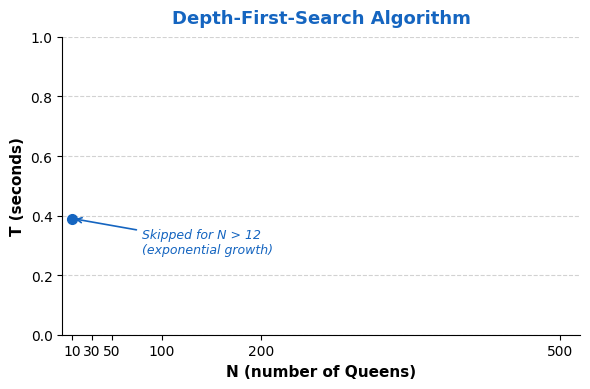

Saved: fig_dfs.png


In [69]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")

# Plot only the N=10 point (DFS is skipped for all others)
ax.plot([N_vals[0]], [dfs_time[0]], color=colors["DFS"],
        marker=MARKER, ms=MSIZE, lw=LW)

ax.annotate("Skipped for N > 12\n(exponential growth)",
            xy=(10, dfs_time[0]),
            xytext=(80, dfs_time[0] * 0.7),
            arrowprops=dict(arrowstyle="->", color=colors["DFS"], lw=1.2),
            fontsize=9, color=colors["DFS"], style="italic")

bold_title(ax, "Depth-First-Search Algorithm", colors["DFS"])
style_ax(ax)
ax.set_xticks(N_vals)
ax.set_xlim(0, 520)
ax.set_ylim(0, max(dfs_time[0] * 2, 1))
plt.tight_layout()
plt.savefig("fig_dfs.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_dfs.png")

## Figure 2 — Greedy Hill Climbing Runtime

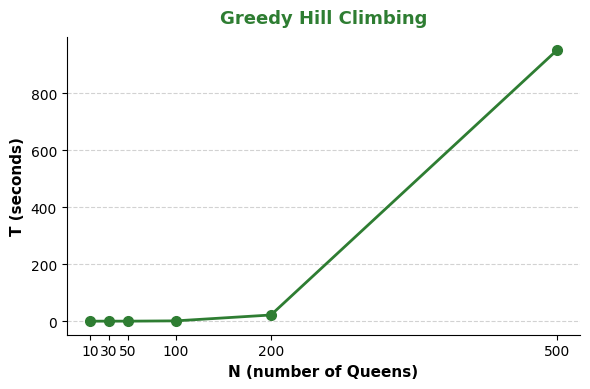

Saved: fig_greedy.png


In [71]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")

ax.plot(N_vals, grdy_time, color=colors["Greedy"],
        marker=MARKER, ms=MSIZE, lw=LW)

bold_title(ax, "Greedy Hill Climbing", colors["Greedy"])
style_ax(ax)
ax.set_xticks(N_vals)
plt.tight_layout()
plt.savefig("fig_greedy.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_greedy.png")

## Figure 3 — Simulated Annealing Runtime

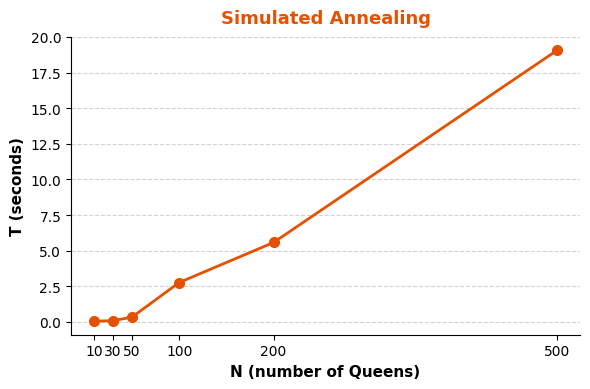

Saved: fig_sa.png


In [73]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")

ax.plot(N_vals, sa_time, color=colors["SA"],
        marker=MARKER, ms=MSIZE, lw=LW)

bold_title(ax, "Simulated Annealing", colors["SA"])
style_ax(ax)
ax.set_xticks(N_vals)
plt.tight_layout()
plt.savefig("fig_sa.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_sa.png")

## Figure 4 — Genetic Algorithm Runtime

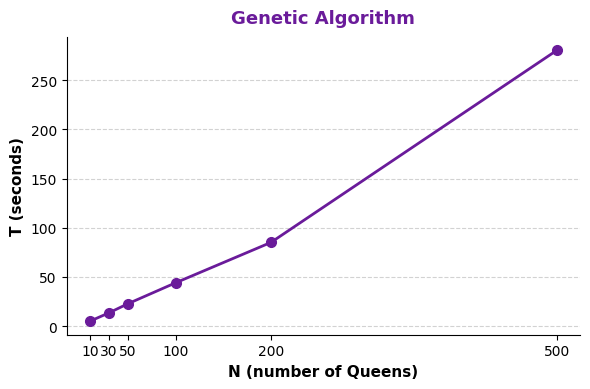

Saved: fig_ga.png


In [75]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")

ax.plot(N_vals, ga_time, color=colors["GA"],
        marker=MARKER, ms=MSIZE, lw=LW)

bold_title(ax, "Genetic Algorithm", colors["GA"])
style_ax(ax)
ax.set_xticks(N_vals)
plt.tight_layout()
plt.savefig("fig_ga.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_ga.png")

## Figure 5 — Simulated Annealing: Remaining Conflicts

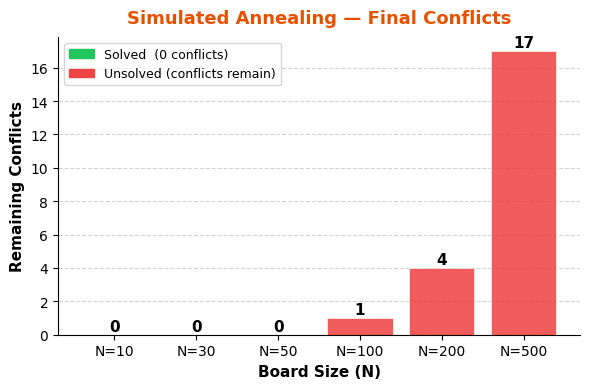

Saved: fig_sa_conflicts.png


In [77]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")

bar_colors = ["#22c55e" if c == 0 else "#ef4444" for c in sa_conflicts]
bars = ax.bar([f"N={n}" for n in N_vals], sa_conflicts,
              color=bar_colors, edgecolor="white", linewidth=0.5, alpha=0.88)

for bar, val in zip(bars, sa_conflicts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            str(val), ha="center", va="bottom",
            fontsize=11, fontweight="bold")

bold_title(ax, "Simulated Annealing — Final Conflicts", colors["SA"])
style_ax(ax, xlabel="Board Size (N)", ylabel="Remaining Conflicts")
ax.yaxis.grid(True, **GRID_KW)
ax.set_axisbelow(True)

solved_p   = mpatches.Patch(color="#22c55e", label="Solved  (0 conflicts)")
unsolved_p = mpatches.Patch(color="#ef4444", label="Unsolved (conflicts remain)")
ax.legend(handles=[solved_p, unsolved_p], fontsize=9)

plt.tight_layout()
plt.savefig("fig_sa_conflicts.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_sa_conflicts.png")

## Figure 6 — Solution Found Heatmap (all algorithms)

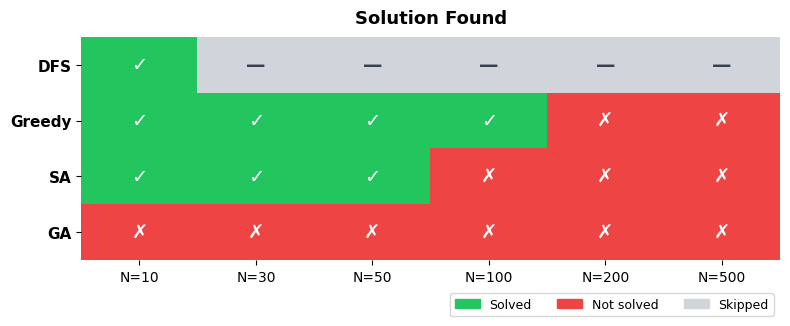

Saved: fig_heatmap.png


In [79]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8, 3.5), facecolor="white")

algs   = ["DFS", "Greedy", "SA", "GA"]
matrix = np.array([[solved[a][i] for i in range(len(N_vals))] for a in algs],
                  dtype=float)

cmap = mcolors.ListedColormap(["#d1d5db", "#ef4444", "#22c55e"])
norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

ax.imshow(matrix, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(len(N_vals)))
ax.set_xticklabels([f"N={n}" for n in N_vals], fontsize=10)
ax.set_yticks(range(len(algs)))
ax.set_yticklabels(algs, fontsize=11, fontweight="bold")
ax.set_title("Solution Found", fontsize=13, fontweight="bold", pad=10)

for i in range(len(algs)):
    for j in range(len(N_vals)):
        v   = matrix[i, j]
        txt = "✓" if v == 1 else ("—" if v == -1 else "✗")
        fc  = "white" if v != -1 else "#374151"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=14, color=fc, fontweight="bold")

legend_patches = [
    mpatches.Patch(color="#22c55e", label="Solved"),
    mpatches.Patch(color="#ef4444", label="Not solved"),
    mpatches.Patch(color="#d1d5db", label="Skipped"),
]
ax.legend(handles=legend_patches, loc="lower right",
          bbox_to_anchor=(1.0, -0.28), ncol=3, fontsize=9)
ax.spines[["top","right","bottom","left"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig_heatmap.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_heatmap.png")

## Figure 7 — Comparative Runtime (Greedy / SA / GA)

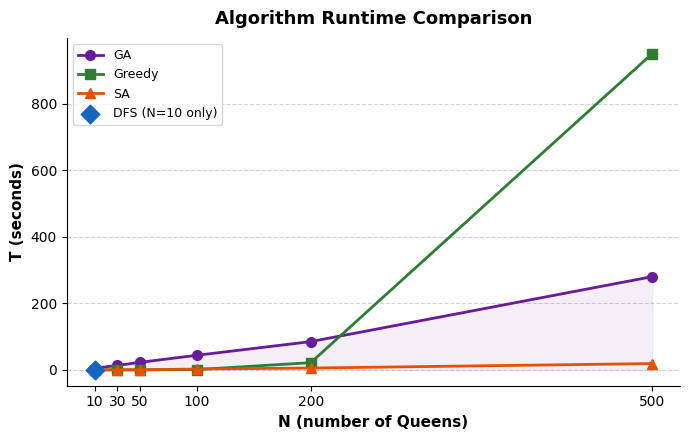

Saved: fig_comparison.png


In [81]:
fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="white")

ax.plot(N_vals, ga_time,   color=colors["GA"],    marker="o", ms=7, lw=2, label="GA")
ax.plot(N_vals, grdy_time, color=colors["Greedy"],marker="s", ms=7, lw=2, label="Greedy")
ax.plot(N_vals, sa_time,   color=colors["SA"],    marker="^", ms=7, lw=2, label="SA")
ax.scatter([N_vals[0]], [dfs_time[0]], color=colors["DFS"],
           marker="D", s=90, zorder=5, label="DFS (N=10 only)")

ax.fill_between(N_vals, ga_time, alpha=0.07, color=colors["GA"])

ax.legend(fontsize=9, loc="upper left", framealpha=0.8)
ax.set_title("Algorithm Runtime Comparison", fontsize=13, fontweight="bold", pad=10)
style_ax(ax)
ax.set_xticks(N_vals)
plt.tight_layout()
plt.savefig("fig_comparison.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_comparison.png")